<a href="https://colab.research.google.com/github/GabCAD92/Machine-learning-tasks/blob/main/Gabriel_Owolabi_iris_multiclass_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiclass Logistic Regression on Iris Dataset

## Objective
This notebook implements multiclass logistic regression using:
- One-vs-All (OvR)
- One-vs-One (OvO)

## Evaluation Metrics
- Accuracy
- Precision
- F1 Score
- Confusion Matrix
- ROC Curve

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, f1_score, roc_curve, auc

## Load and Preprocess Dataset

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data ready!")

Data ready!


## One-vs-Rest (OvR) Strategy

In [3]:
ovr_model = OneVsRestClassifier(LogisticRegression(max_iter=200))
ovr_model.fit(X_train, y_train)

y_pred_ovr = ovr_model.predict(X_test)

acc_ovr = accuracy_score(y_test, y_pred_ovr)
prec_ovr = precision_score(y_test, y_pred_ovr, average='macro')
f1_ovr = f1_score(y_test, y_pred_ovr, average='macro')
cm_ovr = confusion_matrix(y_test, y_pred_ovr)

print("OvR Accuracy:", acc_ovr)
print("OvR Precision:", prec_ovr)
print("OvR F1 Score:", f1_ovr)
print("OvR Confusion Matrix:\n", cm_ovr)

OvR Accuracy: 0.8444444444444444
OvR Precision: 0.8452380952380952
OvR F1 Score: 0.8442714126807563
OvR Confusion Matrix:
 [[15  0  0]
 [ 0 11  4]
 [ 0  3 12]]


## One-vs-One (OvO) Strategy

In [4]:
ovo_model = OneVsOneClassifier(LogisticRegression(max_iter=200))
ovo_model.fit(X_train, y_train)

y_pred_ovo = ovo_model.predict(X_test)

acc_ovo = accuracy_score(y_test, y_pred_ovo)
prec_ovo = precision_score(y_test, y_pred_ovo, average='macro')
f1_ovo = f1_score(y_test, y_pred_ovo, average='macro')
cm_ovo = confusion_matrix(y_test, y_pred_ovo)

print("OvO Accuracy:", acc_ovo)
print("OvO Precision:", prec_ovo)
print("OvO F1 Score:", f1_ovo)
print("OvO Confusion Matrix:\n", cm_ovo)

OvO Accuracy: 0.9111111111111111
OvO Precision: 0.9155354449472096
OvO F1 Score: 0.9107142857142857
OvO Confusion Matrix:
 [[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]


## ROC Curve (OvR)
ROC is plotted using OvR because it supports probability outputs for multiclass problems.

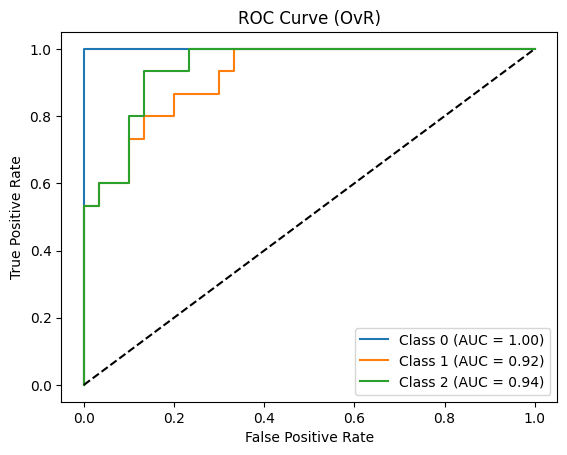

In [5]:
y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_score = ovr_model.predict_proba(X_test)

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (OvR)")
plt.legend()
plt.show()